In [ ]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
# from dotenv import load_dotenv

# from langchain_openai import ChatOpenAI
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq


#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


llm=ChatGroq(model="openai/gpt-oss-120b")

In [ ]:
# model = ChatOpenAI()

In [3]:
MAX_TOKENS = 150

In [4]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = llm.invoke(messages)

    return {"messages": [response]}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [6]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

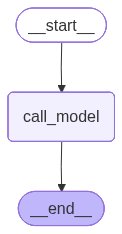

In [7]:
graph

In [8]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Sushant."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is Sushant.


'Hello Sushant! 👋 Nice to meet you. How can I assist you today?'

In [9]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 41
Hi, my name is Sushant.
Hello Sushant! 👋 Nice to meet you. How can I assist you today?
I am learning LangGraph.


'That’s great! LangGraph is a powerful library for building composable, state‑driven workflows with LLMs. Here’s a quick roadmap to help you get up to speed, plus some hands‑on examples you can try right away.\n\n---\n\n## 1️⃣ What LangGraph Is (in a nutshell)\n\n| Concept | What it means | Why it matters |\n|---------|---------------|----------------|\n| **Node** | A single “step” in a graph – can be a prompt, a tool call, a custom Python function, etc. | Encapsulates a piece of logic you can reuse. |\n| **Edge** | The connection between nodes that determines the next step based on the current **state**. | Lets you create conditional flows (if/else, loops, branching). |\n| **State** | A dict‑like object that travels through the graph, holding inputs, outputs, and any intermediate data. | Makes the whole workflow deterministic and easy to debug. |\n| **Graph** | The collection of nodes + edges + a **state schema**. | The actual executable workflow. |\n| **Executor** | Runs the graph (s

In [10]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'**Short‑term memory (STM)**—sometimes called *working memory*—is the brain’s temporary storage system for information that we need to keep “online” for a few seconds to a few minutes. It lets us hold and manipulate data long enough to use it for ongoing tasks, such as remembering a phone number while we dial it or keeping the last few words of a sentence while we understand its meaning.\n\n---\n\n## 1. Core Characteristics\n\n| Feature | Typical Values | What It Means |\n|---------|----------------|---------------|\n| **Capacity** | 7\u202f±\u202f2 “chunks” of information (Miller, 1956) – modern estimates often 4\u202f±\u202f1 chunks | A “chunk” can be a single digit, a word, a familiar acronym, or any unit that has been grouped into a meaningful whole. |\n| **Duration** | 15–30\u202fseconds without rehearsal; can be extended indefinitely with active rehearsal (e.g., silently repeating a phone number) | Information fades quickly unless we rehearse or encode it into long‑term memory. |

In [11]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


'I don’t have any information about your name. If you’d like to share it, feel free to let me know!'

In [12]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Sushant.
------------------------------------------------------------------------------------------------------------------------
Hello Sushant! 👋 Nice to meet you. How can I assist you today?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That’s great! LangGraph is a powerful library for building composable, state‑driven workflows with LLMs. Here’s a quick roadmap to help you get up to speed, plus some hands‑on examples you can try right away.

---

## 1️⃣ What LangGraph Is (in a nutshell)

| Concept | What it means | Why it matters |
|---------|---------------|----------------|
| **Node** | A single “step” in a graph – can be a prompt, a tool call, a custom Python function, etc. | Encapsulates a piece of logic you can reuse. |
| **Edge** | The connectio